# Notebook 01: Exploratory Data Analysis

**Project:** Quantifying Politeness in Online Educational Forums  
**Purpose:** First-pass exploration of the Stanford MOOC forum dataset to understand structure, distributions and data quality before modelling  
**Author:** Karan Raman  
**Input:** data/raw/stanfordMOOCForumPostsSet.xlsx 
**Output:** data/processed/posts_eda.parquet

## 0. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
mpl.rcParams.update({
    'figure.figsize'    : (10, 6),
    'figure.dpi'        : 120,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'savefig.facecolor' : 'white',
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'grid.alpha'        : 0.3,
})

BLUE, RED, GREEN, GREY = '#2166AC', '#D6604D', '#1A9641', '#878787'
sns.set_palette([BLUE, RED, GREEN, GREY, '#F4A582'])

DATA_RAW       = Path('../data/raw')
DATA_PROCESSED = Path('../data/processed')
DATA_OUT       = Path('../data/outputs')
DATA_OUT.mkdir(parents=True, exist_ok=True)

print('Import successful')

Import successful



## 1. Load the data

In [2]:
# Load dataset
df = pd.read_excel(DATA_RAW / 'stanfordMOOCForumPostsSet.xlsx')

print(f'Rows: {len(df):,}')
print(f'Columns: {df.shape[1]}')
print(f'\nColumn names:')
for col in df.columns:
    print(f'  {col}: {df[col].dtype}')

Rows: 29,604
Columns: 18

Column names:
  Text: object
  Opinion(1/0): int64
  Question(1/0): int64
  Answer(1/0): int64
  Sentiment(1-7): float64
  Confusion(1-7): float64
  Urgency(1-7): float64
  CourseType: str
  forum_post_id: object
  course_display_name: str
  forum_uid: object
  created_at: datetime64[us]
  post_type: str
  anonymous: float64
  anonymous_to_peers: float64
  up_count: float64
  comment_thread_id: object
  reads: float64


In [3]:
# Preview first three rows
df.head(3)

,Text,Opinion(1/0),Question(1/0),Answer(1/0),Sentiment(1-7),Confusion(1-7),Urgency(1-7),CourseType,forum_post_id,course_display_name,forum_uid,created_at,post_type,anonymous,anonymous_to_peers,up_count,comment_thread_id,reads
0,Interesting! How often we say those things to ...,1,0,0,6.5,2.0,1.5,Education,5225177f2c501f0a00000015,Education/EDUC115N/How_to_Learn_Math,30CADB93E6DE4711193D7BD05F2AE95C,2013-09-02 22:55:59,Comment,0.0,0.0,0.0,5221a8262cfae31200000001,41.0
1,"What is \Algebra as a Math Game\"" or are you j...",0,1,0,4.0,5.0,3.5,Education,5207d0e9935dfc0e0000005e,Education/EDUC115N/How_to_Learn_Math,37D8FAEE7D0B94B6CFC57D98FD3D0BA5,2013-08-11 17:59:05,Comment,0.0,0.0,0.0,520663839df35b0a00000043,55.0
2,I like the idea of my kids principal who says ...,1,0,0,5.5,3.0,2.5,Education,52052c82d01fec0a00000071,Education/EDUC115N/How_to_Learn_Math,CC11480215042B3EB6E5905EAB13B733,2013-08-09 17:53:06,Comment,0.0,0.0,0.0,51e59415e339d716000001a6,25.0


## 2. Data quality: missing values, duplicates, empty/short posts

In [4]:
# Missing values per column
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary.missing_count > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct
comment_thread_id,12306,41.57
forum_uid,19,0.06
created_at,19,0.06
post_type,19,0.06
anonymous,19,0.06
anonymous_to_peers,19,0.06
up_count,19,0.06
reads,19,0.06
forum_post_id,14,0.05
course_display_name,13,0.04


In [5]:
# Duplicate posts
dupes = df.duplicated(subset='forum_post_id').sum()
print(f'Duplicate post IDs: {dupes}')

# Empty / very short text posts
df['text_length'] = df['Text'].fillna('').str.split().str.len()
print(f'Posts with 0 words: {(df.text_length == 0).sum()}')
print(f'Posts with <5 words: {(df.text_length < 5).sum()}')

Duplicate post IDs: 16
Posts with 0 words: 1
Posts with <5 words: 1364



## 3. Post type distribution
Understanding the balance of opinions, questions and answers.

In [6]:
df = df.rename(columns={
    'Opinion(1/0)': 'Opinion',
    'Question(1/0)': 'Question',
    'Answer(1/0)': 'Answer',
    'Sentiment(1-7)': 'Sentiment',
    'Confusion(1-7)': 'Confusion',
    'Urgency(1-7)': 'Urgency'
})

In [7]:
# Structural post type
print('Structural post type distribution:')
print(df['post_type'].value_counts().to_string())

Structural post type distribution:
post_type
Comment          17298
CommentThread    12287


In [8]:
# Content flags (what a post is about (non-exclusive))
for col in ['Opinion', 'Question', 'Answer']:
    n = int(df[col].sum())
    pct = n / len(df) * 100
    print(f'{col:<10}: {n:,} ({pct:.1f}%)')

Opinion   : 16,469 (55.6%)
Question  : 5,959 (20.1%)
Answer    : 6,055 (20.5%)


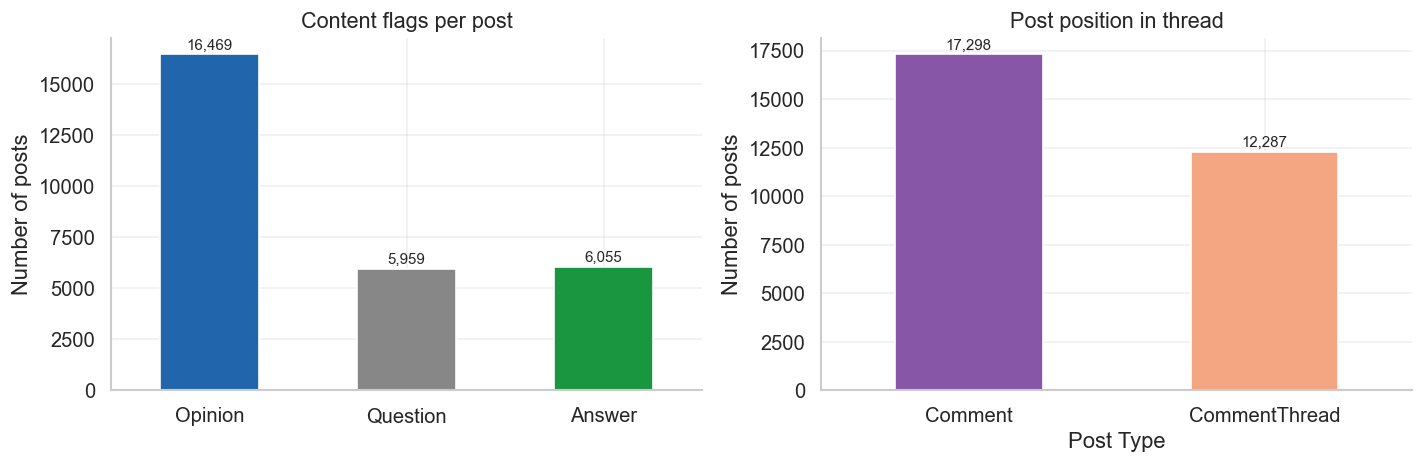

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
type_counts = {col: int(df[col].sum()) for col in ['Opinion', 'Question', 'Answer']}

def add_labels(ax):
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 100,
                f'{int(bar.get_height()):,}',
                ha='center', va='bottom', fontsize=9)

pd.Series(type_counts).plot(kind='bar', ax=axes[0], color=[BLUE, GREY, GREEN])
axes[0].set_title('Content flags per post')
axes[0].set_ylabel('Number of posts')
axes[0].tick_params(axis='x', rotation=0)
add_labels(axes[0])

df['post_type'].dropna().value_counts().plot(kind='bar', ax=axes[1], color=['#8856a7', '#F4A582'])
axes[1].set_title('Post position in thread')
axes[1].set_ylabel('Number of posts')
axes[1].set_xlabel('Post Type')
axes[1].tick_params(axis='x', rotation=0)
add_labels(axes[1])

plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_post_type_distribution.png')
plt.show()


## 4. Course distribution
Understanding how posts spread across courses and course types.

In [10]:
# Note: counts below are from raw data before cleaning
print(f'Unique course display names : {df.course_display_name.nunique()}')
print(f'Unique user IDs             : {df.forum_uid.nunique():,}')
print(f'Unique thread IDs           : {df.comment_thread_id.nunique():,}')

print('\nCourse type distribution (raw data):')
print(df['CourseType'].value_counts().to_string())

Unique course display names : 11
Unique user IDs             : 11,042
Unique thread IDs           : 8,271

Course type distribution (raw data):
CourseType
Medicine      10001
Education      9878
Humanities     9723


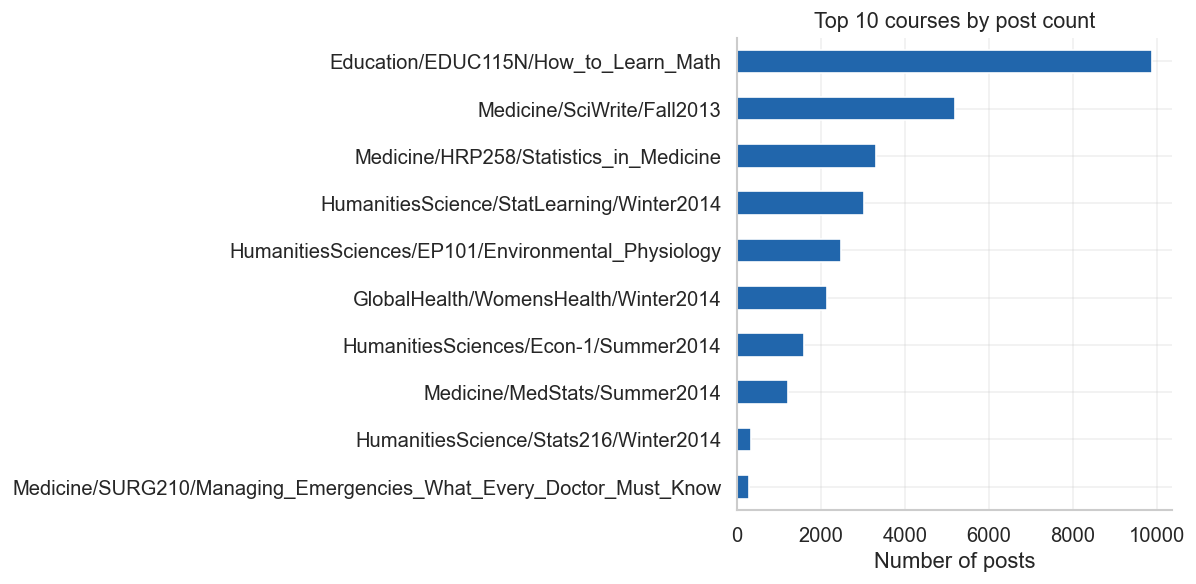

In [11]:
top_courses = df['course_display_name'].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
top_courses.plot(kind='barh', ax=ax, color=BLUE)
ax.set_title('Top 10 courses by post count')
ax.set_xlabel('Number of posts')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_top_courses.png')
plt.show()

## 5. Engagement metrics
Exploring upvotes, reads, and anonymity patterns.

In [12]:
for col, label in [('up_count', 'Upvotes'), ('reads', 'Reads')]:
    print(f'{label}:')
    print(df[col].describe().round(2).to_string())
    print()

print(f'Anonymous posts     : {int(df.anonymous.sum()):,} ({df.anonymous.mean()*100:.1f}%)')
print(f'Anonymous to peers  : {int(df.anonymous_to_peers.sum()):,} ({df.anonymous_to_peers.mean()*100:.1f}%)')

Upvotes:
count    29585.00
mean         0.40
std          2.02
min          0.00
25%          0.00
50%          0.00
75%          0.00
max        191.00

Reads:
count    29585.00
mean       410.74
std       1245.33
min          0.00
25%         16.00
50%         65.00
75%        191.00
max       9452.00

Anonymous posts     : 512 (1.7%)
Anonymous to peers  : 0 (0.0%)



## 6. Existing annotation distributions
Sentiment, confusion, and urgency are pre-labelled on a 1–7 scale

In [13]:
print('Annotation score statistics:')
print(df[['Sentiment', 'Confusion', 'Urgency']].describe().round(2).to_string())

Annotation score statistics:
       Sentiment  Confusion   Urgency
count   29604.00   29604.00  29604.00
mean        4.18       3.91      2.74
std         0.69       0.61      1.40
min         1.00       1.00      1.00
25%         4.00       3.50      1.50
50%         4.00       4.00      2.50
75%         4.50       4.00      3.50
max         7.00       7.00      7.00


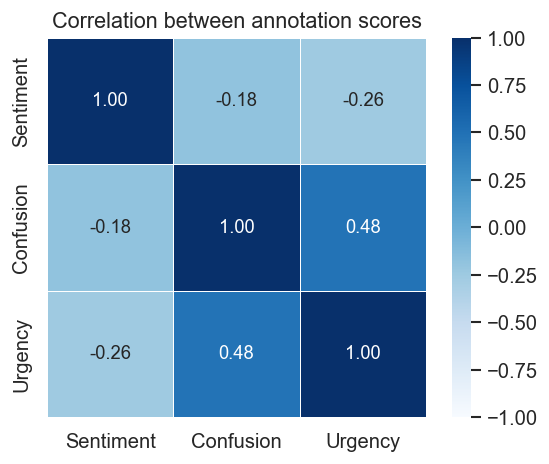

In [14]:
corr = df[['Sentiment', 'Confusion', 'Urgency']].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues',
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation between annotation scores')
plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_annotation_correlation.png')
plt.show()

## 7. Text length distribution

Word count per post:
count    29598.0
mean        59.4
std         63.2
min          1.0
25%         19.0
50%         40.0
75%         75.0
max        497.0


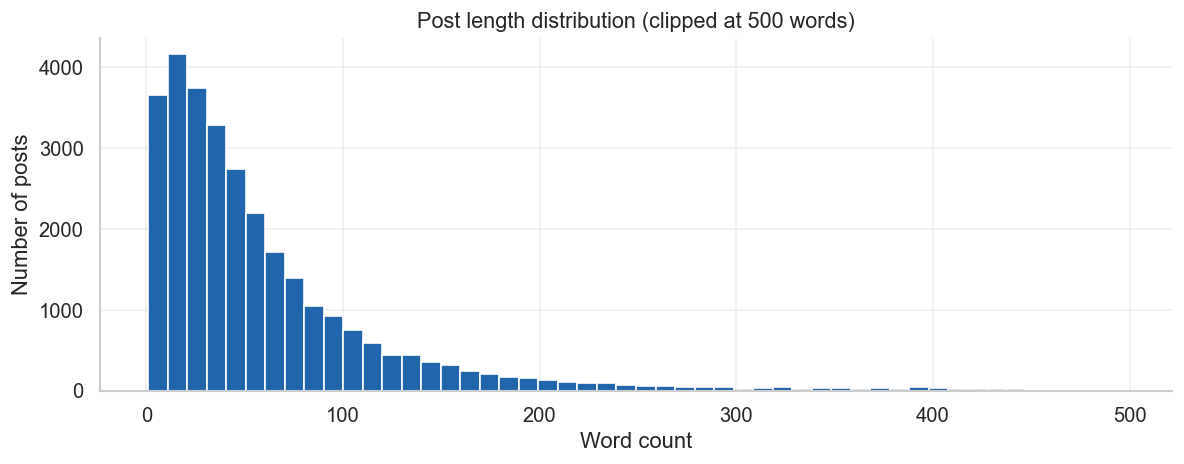

In [15]:
df['word_count'] = df['Text'].str.split().str.len()

print('Word count per post:')
print(df['word_count'].describe().round(1).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
df['word_count'].clip(upper=500).plot(kind='hist', bins=50, ax=ax,
                                      color=BLUE, edgecolor='white')
ax.set_title('Post length distribution (clipped at 500 words)')
ax.set_xlabel('Word count')
ax.set_ylabel('Number of posts')
plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_text_length.png')
plt.show()

## 8. Temporal distribution
When are posts being made? Useful for understanding response timing patterns.

In [16]:
df['created_at']  = pd.to_datetime(df['created_at'])
df['month']       = df['created_at'].dt.to_period('M')
df['hour_of_day'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.day_name()

print(f'Date range  : {df.created_at.min().date()} to {df.created_at.max().date()}')
print(f'Months      : {df.month.nunique()}')
print(f'Posts/month : {len(df) / df.month.nunique():.0f} avg')

Date range  : 2013-06-09 to 2014-08-08
Months      : 15
Posts/month : 1974 avg


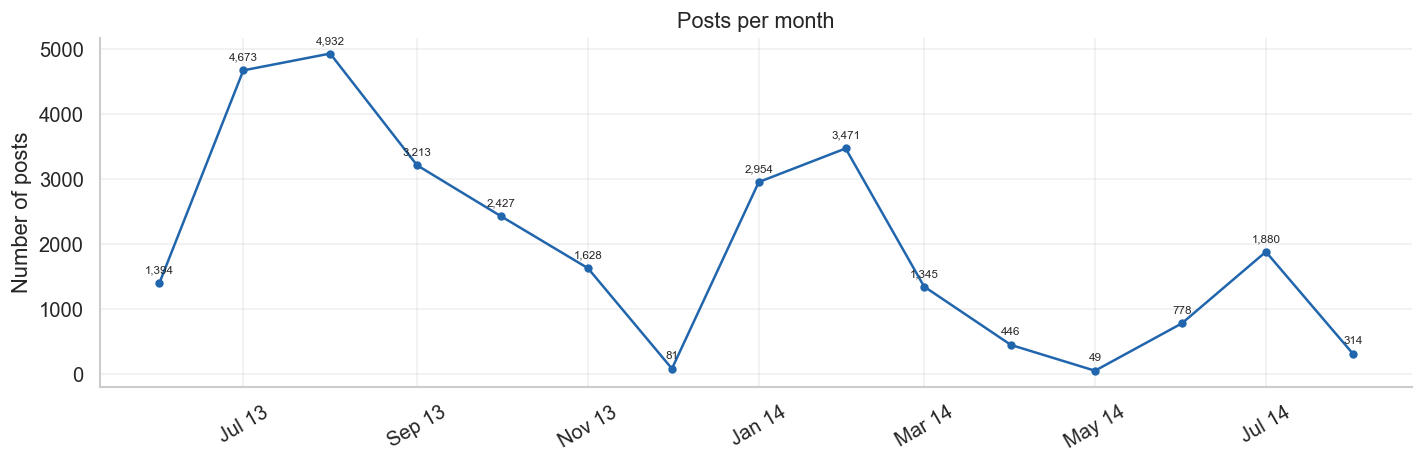

In [17]:
# Posts per month
fig, ax = plt.subplots(figsize=(12, 4))
monthly = df.groupby('month').size()
monthly.index = monthly.index.to_timestamp()
ax.plot(monthly.index, monthly.values, color=BLUE, marker='o', markersize=4)
for x, y in zip(monthly.index, monthly.values):
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points',
                xytext=(0, 6), ha='center', fontsize=7)
ax.set_title('Posts per month')
ax.set_ylabel('Number of posts')
ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%b %y'))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_posts_per_month.png')
plt.show()

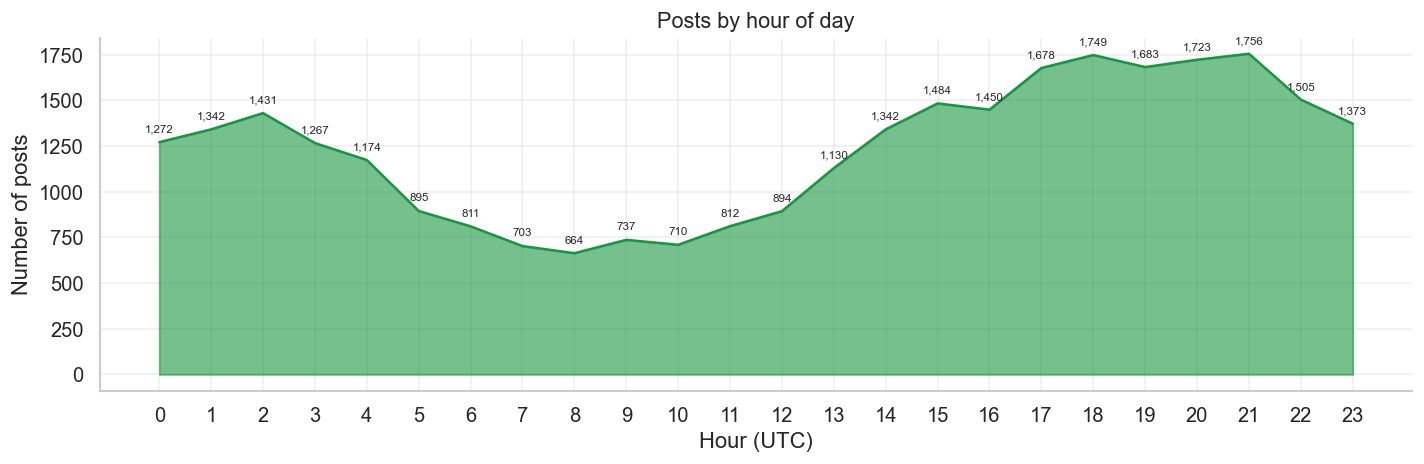

In [18]:
# Posts by hour of day
fig, ax = plt.subplots(figsize=(12, 4))
hourly = df['hour_of_day'].value_counts().sort_index()
ax.fill_between(hourly.index, hourly.values, color=GREEN, alpha=0.6)
ax.plot(hourly.index, hourly.values, color=GREEN)
for x, y in zip(hourly.index, hourly.values):
    ax.annotate(f'{y:,}', (x, y), textcoords='offset points',
                xytext=(0, 6), ha='center', fontsize=7)
ax.set_title('Posts by hour of day')
ax.set_xlabel('Hour (UTC)')
ax.set_ylabel('Number of posts')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_posts_by_hour.png')
plt.show()

## 9. Role Label Investigation

In [19]:
print('Role label check')
role_cols = [c for c in df.columns if any(
    kw in c.lower() for kw in ['role', 'instructor', 'student', 'staff', 'teacher']
)]
print(f'Role columns found : {role_cols if role_cols else "none"}')
print(f'Unique user IDs    : {df["forum_uid"].nunique():,} anonymised')
print(f'post_type values   : {df["post_type"].unique().tolist()}')
print(f'Anonymous posts    : {int(df["anonymous"].sum()):,}')
print('No role metadata present in this dataset.')

Role label check
Role columns found : none
Unique user IDs    : 11,042 anonymised
post_type values   : ['Comment', 'CommentThread', nan]
Anonymous posts    : 512
No role metadata present in this dataset.


## 10. Response Timing Exploration

In [20]:
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

thread_first = (df.groupby('comment_thread_id')['created_at']
                .min().rename('thread_start_time'))
df = df.merge(thread_first, on='comment_thread_id', how='left')
df['response_time_hours'] = (
    df['created_at'] - df['thread_start_time']
).dt.total_seconds() / 3600

bins   = [-0.01, 1, 24, 168, float('inf')]
labels = ['< 1 hr', '1-24 hrs', '1-7 days', '> 7 days']
df['response_time_bin'] = pd.cut(df['response_time_hours'], bins=bins, labels=labels)

thread_sizes = df.groupby('comment_thread_id').size()
print(f'Unique threads     : {thread_sizes.shape[0]:,}')
print(f'Single post threads: {(thread_sizes == 1).sum():,}')
print(f'Multi post threads : {(thread_sizes >= 2).sum():,}')
print(df['response_time_hours'].describe().round(2).to_string())

Unique threads     : 8,271
Single post threads: 5,053
Multi post threads : 3,218
count    17298.00
mean        60.82
std        215.35
min          0.00
25%          0.00
50%          0.53
75%         27.90
max      10092.32


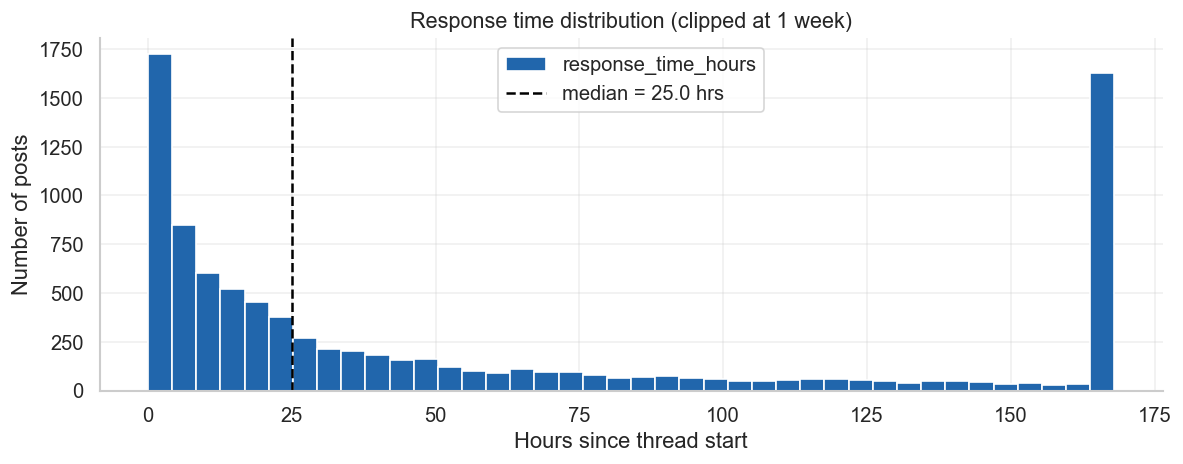

In [21]:
valid_rt = df['response_time_hours'].dropna()
valid_rt = valid_rt[valid_rt > 0].clip(upper=168)

fig, ax = plt.subplots(figsize=(10, 4))
valid_rt.plot(kind='hist', bins=40, ax=ax, color=BLUE, edgecolor='white')
ax.axvline(valid_rt.median(), color='black', linestyle='--',
           label=f'median = {valid_rt.median():.1f} hrs')
ax.set_title('Response time distribution (clipped at 1 week)')
ax.set_xlabel('Hours since thread start')
ax.set_ylabel('Number of posts')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_response_timing.png')
plt.show()

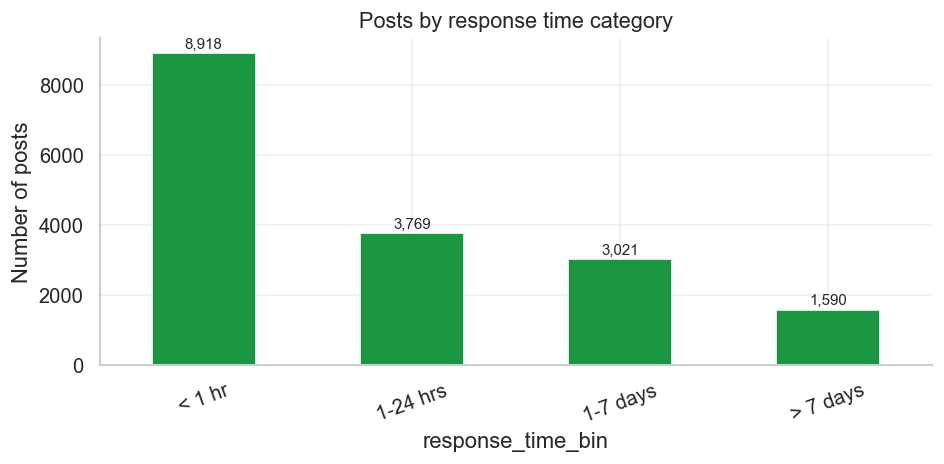

In [22]:
rt_counts = df['response_time_bin'].value_counts().reindex(labels)
fig, ax = plt.subplots(figsize=(8, 4))
rt_counts.plot(kind='bar', ax=ax, color=GREEN, edgecolor='white')
ax.set_title('Posts by response time category')
ax.set_ylabel('Number of posts')
ax.tick_params(axis='x', rotation=20)

for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 50,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(DATA_OUT / 'fig_response_bins.png')
plt.show()

## 11. Save output file

In [23]:
# Summary of notebook
print(f'Total posts        : {len(df):,}')
print(f'Date range         : {df.created_at.min().date()} to {df.created_at.max().date()}')
print(f'Unique users       : {df.forum_uid.nunique():,}')
print(f'Anonymous posts    : {int(df.anonymous.sum()):,}')
print(f'Multi-post threads : {(df.groupby("comment_thread_id").size() >= 2).sum():,}')
print(f'Median response    : {df["response_time_hours"][df["response_time_hours"]>0].median():.1f} hrs')

Total posts        : 29,604
Date range         : 2013-06-09 to 2014-08-08
Unique users       : 11,042
Anonymous posts    : 512
Multi-post threads : 3,218
Median response    : 25.0 hrs


In [24]:
# Save a clean copy of the dataframe 
# Convert Text to string to fix mixed types
df['Text'] = df['Text'].astype(str)

In [25]:
# Fix all object columns with mixed types
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str)

# Save
df.to_parquet(DATA_OUT / 'posts_eda.parquet', index=False)
print('Saved to data/processed/posts_eda.parquet')

Saved to data/processed/posts_eda.parquet


/var/folders/yn/c12lq2sn20j1_ny3nyjp3s0w0000gn/T/ipykernel_13966/1558295456.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:
